In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve
%matplotlib inline

In [5]:
readFname = '../../WPWP_GLORYS_data/temp_eq/concatenated.nc'
fullDS = xr.open_dataset(readFname)

In [6]:
fullDS

<xarray.Dataset> Size: 9GB
Dimensions:    (time: 4011, longitude: 2245, depth: 28)
Coordinates:
  * time       (time) datetime64[ns] 32kB 2014-01-01T12:00:00 ... 2024-12-24
  * longitude  (longitude) float32 9kB 109.0 109.1 109.2 ... 295.8 295.9 296.0
  * depth      (depth) float32 112B 0.494 1.541 2.646 ... 186.1 222.5 266.0
    latitude   float32 4B ...
Data variables:
    mlotst     (time, longitude) float64 72MB ...
    zos        (time, longitude) float64 72MB ...
    bottomT    (time, longitude) float64 72MB ...
    sithick    (time, longitude) float64 72MB ...
    siconc     (time, longitude) float64 72MB ...
    usi        (time, longitude) float64 72MB ...
    vsi        (time, longitude) float64 72MB ...
    thetao     (time, depth, longitude) float64 2GB ...
    so         (time, depth, longitude) float64 2GB ...
    uo         (time, depth, longitude) float64 2GB ...
    vo         (time, depth, longitude) float64 2GB ...
Attributes: (12/25)
    title:              daily mean fields from Global Ocean Physics Analysis ...
    easting:            longitude
    northing:           latitude
    history:            Sun Nov 16 21:27:44 2025: ncrcat GLORYS12v1_dailyAvg_...
    source:             MERCATOR GLORYS12V1
    institution:        MERCATOR OCEAN
    ...                 ...
    longitude_max:      179.91667
    latitude_min:       -80.0
    latitude_max:       90.0
    z_min:              0.494025
    z_max:              5727.917
    NCO:                netCDF Operators version 5.3.3 (Homepage = http://nco...

In [7]:
fullDS['thetao_trend'] = (fullDS['thetao'].roll(time=-1) - fullDS['thetao'])
fullDS = fullDS.isel(time=slice(0,-1))

fullDS = fullDS.sel(longitude=slice(130,275))
fullDS = fullDS.interpolate_na(
    dim="longitude", method="linear"
).interpolate_na(
    dim="time", method="linear"
)

longitudes = fullDS['longitude'].to_numpy()
dates = fullDS['time'].to_numpy()


In [9]:
temp_trend = fullDS['thetao_trend'].to_numpy()
temp = fullDS['thetao'].to_numpy()

zos = fullDS['zos'].to_numpy()
mlotst = fullDS['mlotst'].to_numpy()
uo = fullDS['uo'].to_numpy()

In [11]:
zos.shape, uo.shape, temp.shape

((4010, 1741), (4010, 28, 1741), (4010, 28, 1741))

In [13]:
klen = 121
hklen = int(klen//2)
kernel = np.ones((klen,1,1))
kernel /= np.sum(kernel)

kernel_2d = np.ones((klen,1))
kernel_2d /= np.sum(kernel_2d)

dtT = convolve(temp_trend, kernel, mode='valid')
T = convolve(temp, kernel, mode='valid')
uvel = convolve(uo, kernel, mode='valid')

ssh = convolve(zos, kernel_2d, mode='valid')
mld = convolve(mlotst, kernel_2d, mode='valid')


In [ ]:
T_top = 0.5 * (T + np.roll(T, 1, axis=1))
T_top[:,0,:] = T[:,0,:]
T_bottom = 0.5 * (T + np.roll(T, -1, axis=1))
dT_dz = T_top - T_bottom)

Text(0.5, 1.0, 'Zoanl Surf. Vel.')

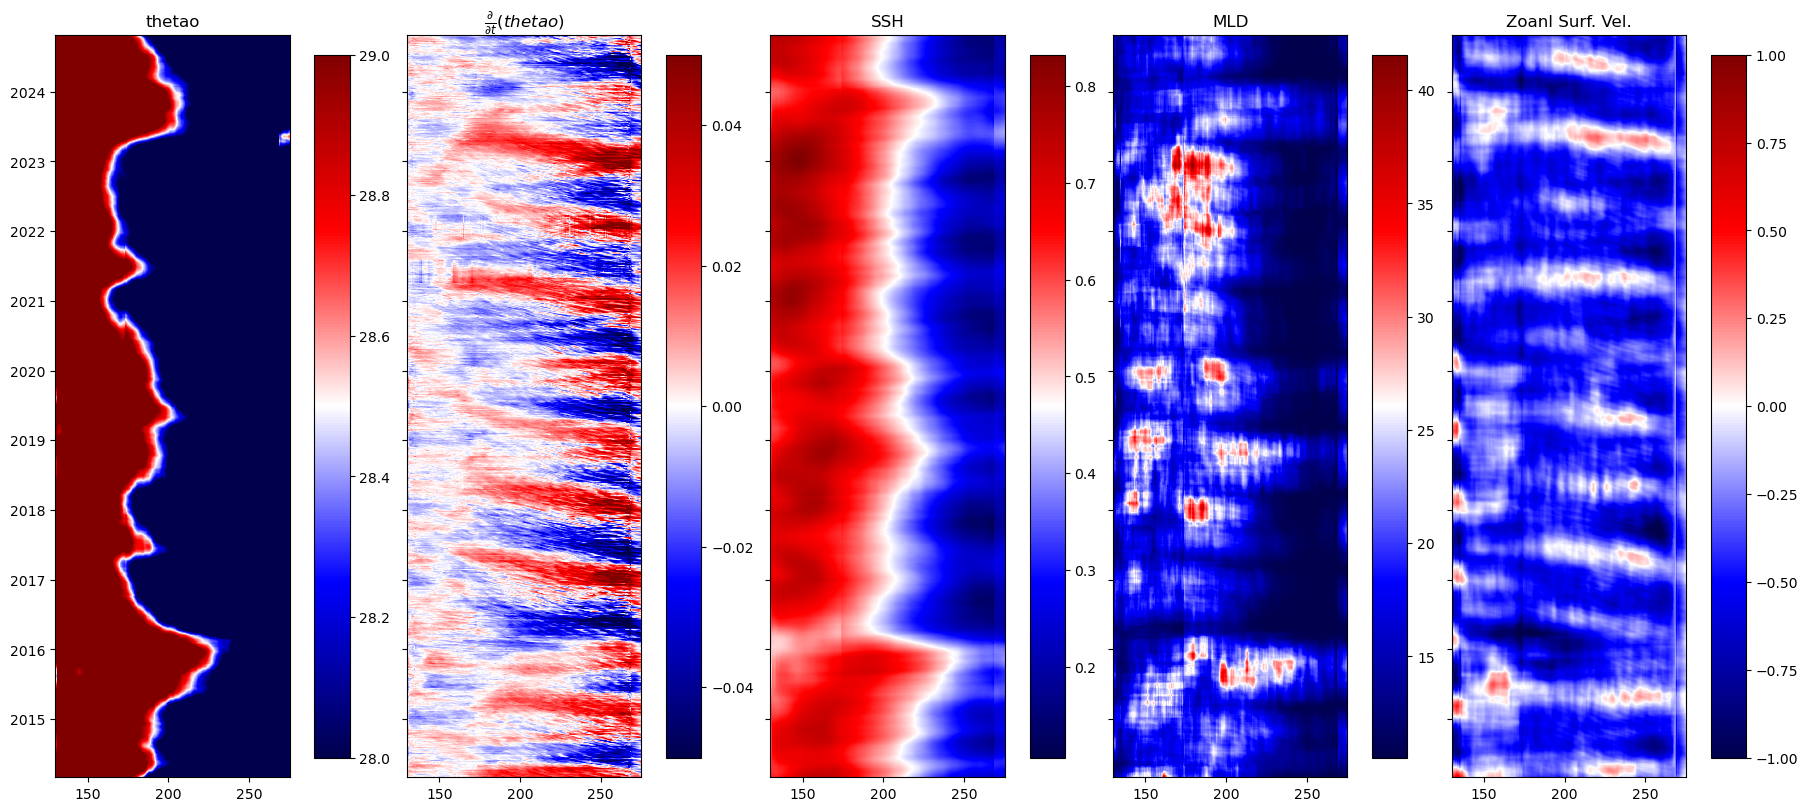

In [14]:





fig, axes = plt.subplots(ncols=5, figsize=(18, 8), constrained_layout=True, sharey = True)
cmap = plt.cm.seismic

ax = axes[0]
vmin, vmax = 28, 29
titleStr = 'thetao'
pmesh = ax.pcolormesh(longitudes, dates[hklen:-hklen], T[:,0,:], vmin=vmin, vmax=vmax, cmap=cmap, shading='auto')
plt.colorbar(pmesh, ax= ax)
ax.set_title(titleStr)

ax = axes[1]
vmin, vmax = -0.05, 0.05
titleStr = r'$\frac{\partial}{\partial t} (thetao)$'
pmesh = ax.pcolormesh(longitudes, dates[hklen:-hklen], dtT[:,0,:], vmin=vmin, vmax=vmax, cmap=cmap, shading='auto')
plt.colorbar(pmesh, ax= ax)
ax.set_title(titleStr)

ax = axes[2]
vmin, vmax = -0.05, 0.05
titleStr = 'SSH'
pmesh = ax.pcolormesh(longitudes, dates[hklen:-hklen], ssh ,cmap=cmap)#, vmin=vmin, vmax=vmax,  shading='auto')
plt.colorbar(pmesh, ax= ax)
ax.set_title(titleStr)


ax = axes[3]
vmin, vmax = -0.05, 0.05
titleStr = 'MLD'
pmesh = ax.pcolormesh(longitudes, dates[hklen:-hklen], mld ,cmap=cmap)#, vmin=vmin, vmax=vmax,  shading='auto')
plt.colorbar(pmesh, ax= ax)
ax.set_title(titleStr)

ax = axes[4]
vmin, vmax = -1, 1
titleStr = 'Zoanl Surf. Vel.'
pmesh = ax.pcolormesh(longitudes, dates[hklen:-hklen], uvel[:,0,:] ,cmap=cmap, vmin=vmin, vmax=vmax,  shading='auto')
plt.colorbar(pmesh, ax= ax)
ax.set_title(titleStr)

Text(0.5, 1.0, 'Zoanl Surf. Vel.')

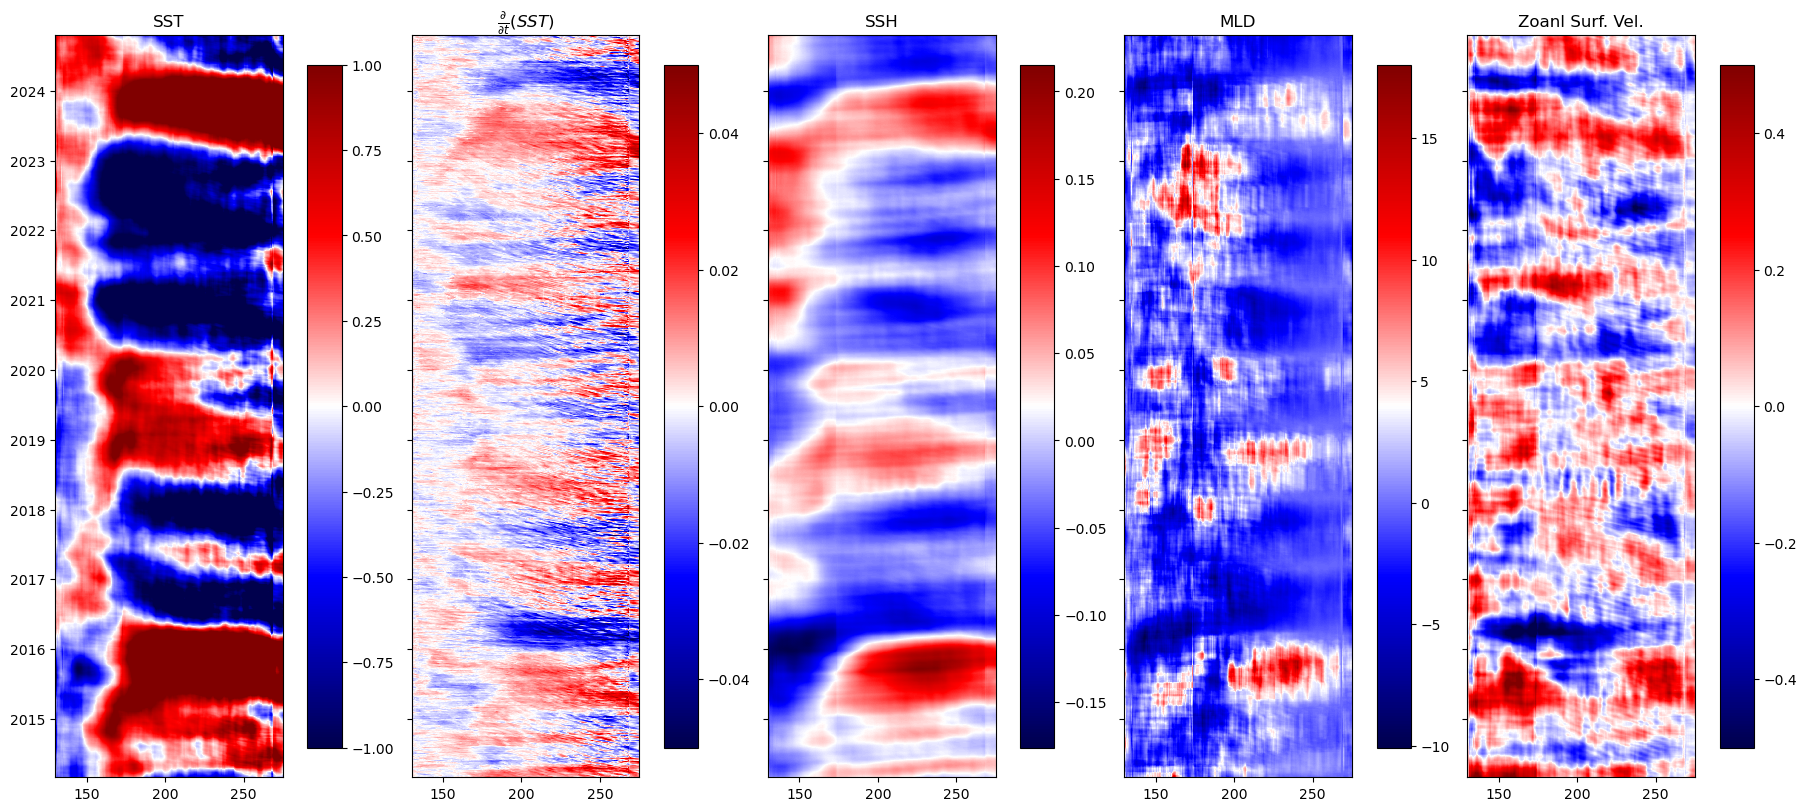

In [33]:
daily_climatology = fullDS.groupby('time.dayofyear').mean('time')
daily_anomalies = fullDS.groupby('time.dayofyear') - daily_climatology

temp_trend = daily_anomalies['thetao_trend'].to_numpy()
temp = daily_anomalies['thetao'].to_numpy()

zos = daily_anomalies['zos'].to_numpy()
mlotst = daily_anomalies['mld'].to_numpy()
uo = daily_anomalies['uo'].to_numpy()


klen = 121
hklen = int(klen//2)
kernel = np.ones((klen,1))
kernel /= np.sum(kernel)

dtT = convolve(temp_trend, kernel, mode='valid')
T = convolve(temp, kernel, mode='valid')

ssh = convolve(zos, kernel, mode='valid')
mld = convolve(mlotst, kernel, mode='valid')
uvel = convolve(uo, kernel, mode='valid')

fig, axes = plt.subplots(ncols=5, figsize=(18, 8), constrained_layout=True, sharey = True)
cmap = plt.cm.seismic

ax = axes[0]
vmin, vmax = -1,1
titleStr = 'thetao'
pmesh = ax.pcolormesh(longitudes, dates[hklen:-hklen], T, vmin=vmin, vmax=vmax, cmap=cmap, shading='auto')
plt.colorbar(pmesh, ax= ax)
ax.set_title(titleStr)

ax = axes[1]
vmin, vmax = -0.05, 0.05
titleStr = r'$\frac{\partial}{\partial t} (thetao)$'
pmesh = ax.pcolormesh(longitudes, dates[hklen:-hklen], dtT, vmin=vmin, vmax=vmax, cmap=cmap, shading='auto')
plt.colorbar(pmesh, ax= ax)
ax.set_title(titleStr)

ax = axes[2]
vmin, vmax = -0.05, 0.05
titleStr = 'SSH'
pmesh = ax.pcolormesh(longitudes, dates[hklen:-hklen], ssh ,cmap=cmap)#, vmin=vmin, vmax=vmax,  shading='auto')
plt.colorbar(pmesh, ax= ax)
ax.set_title(titleStr)


ax = axes[3]
vmin, vmax = -0.05, 0.05
titleStr = 'MLD'
pmesh = ax.pcolormesh(longitudes, dates[hklen:-hklen], mld ,cmap=cmap)#, vmin=vmin, vmax=vmax,  shading='auto')
plt.colorbar(pmesh, ax= ax)
ax.set_title(titleStr)

ax = axes[4]
vmin, vmax = -0.5, 0.5
titleStr = 'Zoanl Surf. Vel.'
pmesh = ax.pcolormesh(longitudes, dates[hklen:-hklen], uvel ,cmap=cmap, vmin=vmin, vmax=vmax,  shading='auto')
plt.colorbar(pmesh, ax= ax)
ax.set_title(titleStr)